In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import sys
sys.path.append('..') 

from simulator.loader import MarketDataLoader
from simulator.hmm import HybridJumpsHMM
from simulator.single_index import SingleIndexModel
from experts.markowitz import MarkowitzExpert

with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

market_ticker = config["data"]["market_ticker"]
stock_tickers = config["data"]["stock_tickers"]

loader = MarketDataLoader(
    tickers=[market_ticker] + stock_tickers,
    start_date=config["data"]["start_date"],
    end_date=config["data"]["end_date"]
)
data = loader.fetch_data()

market_returns = data[market_ticker]
raw_stock_returns = data[stock_tickers]
stock_returns = raw_stock_returns.to_frame() if isinstance(raw_stock_returns, pd.Series) else raw_stock_returns

print("Fitting models...")
hmm = HybridJumpsHMM(n_states=config["hmm"]["n_states"])
hmm.fit(market_returns)
best_eps, best_lambd = hmm.grid_search(market_returns, max_lag=20, n_paths=10)

sim_model = SingleIndexModel(tickers=stock_tickers)
sim_model.fit(stock_returns, market_returns)

sim_states = hmm.simulate_states(config["hmm"]["simulation"]["n_steps"], best_eps, best_lambd)
sim_stocks = sim_model.simulate(hmm.decode_states(sim_states))
print("Simulation complete!")

Fitting models...
Simulation complete!


In [11]:
expert = MarkowitzExpert(
    risk_aversion=config["expert"]["risk_aversion"],
    rolling_window=config["expert"]["rolling_window"],
    max_weight=config["expert"]["max_weight"],
    annual_risk_free_rate=config["expert"]["annual_risk_free_rate"]
)

weights_df = expert.generate_labels(sim_stocks)
print(f"Generated Weights Matrix: {weights_df.shape}")

Generated Weights Matrix: (2460, 11)


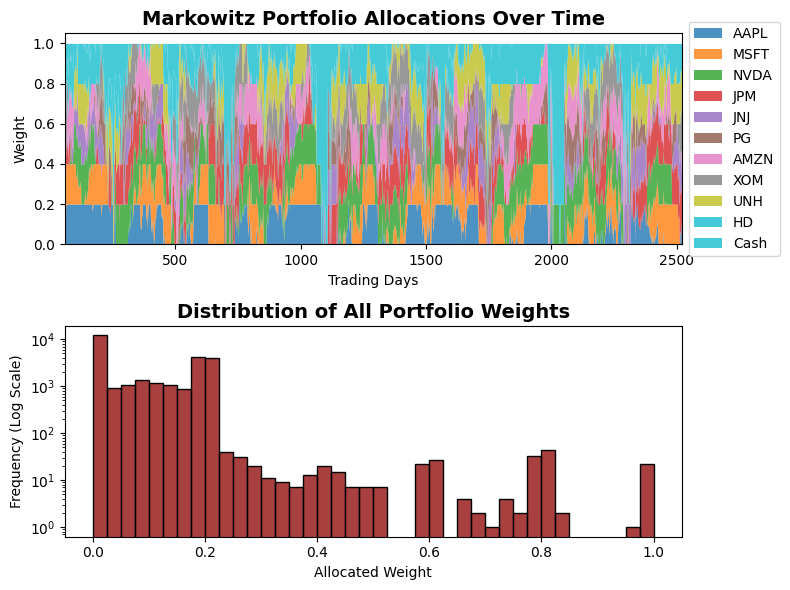

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Plot 1: Stacked Area Chart (Portfolio over time)
weights_df.plot.area(ax=axes[0], colormap='tab10', alpha=0.8, linewidth=0)
axes[0].set_title("Markowitz Portfolio Allocations Over Time", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Weight")
axes[0].set_xlabel("Trading Days")
axes[0].margins(x=0)
axes[0].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

# Plot 2: Histogram (with log scale!)
sns.histplot(weights_df.values.flatten(), bins=40, ax=axes[1], color='darkred')
axes[1].set_title("Distribution of All Portfolio Weights", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Allocated Weight")
axes[1].set_ylabel("Frequency (Log Scale)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()